In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv('stations.csv')

In [3]:
df.head()

,Weather Station ID,Country,Name,Latitude,Longitude,Elevation,ICAO ID,WMO ID,IATA ID,Time Zone
0,PABL0,US,Buckland Airport,65.9667,-161.1500,7.0,PABL,NaN,BKC,NaN
1,1001,NO,Jan Mayen,70.9333,-8.6667,10.0,ENJA,1001.0,NaN,Europe/Oslo
2,1002,NO,Grahuken,79.7833,14.4667,NaN,NaN,1002.0,NaN,Europe/Oslo
3,1003,NO,Hornsund,77.0000,15.5000,10.0,NaN,1003.0,NaN,Europe/Oslo
4,1004,NO,Ny-Alesund Ii,78.9167,11.9333,8.0,ENAS,1004.0,NaN,Europe/Oslo


In [4]:
df.shape

(30409, 10)

A koordináták modulóval történő “wrap-elése” biztosítja, hogy minden pont egy fix, érvényes tartományba essen, így a térképen vagy a klaszterező algoritmusban nem keletkeznek hibás, túlcsordult értékek

In [5]:
df['lat'] = df['Latitude'].map(lambda x: (x+100)%200 - 100)
df['long'] = df['Longitude'].map(lambda x: (x+200)%400 - 200)

<Axes: xlabel='long', ylabel='lat'>

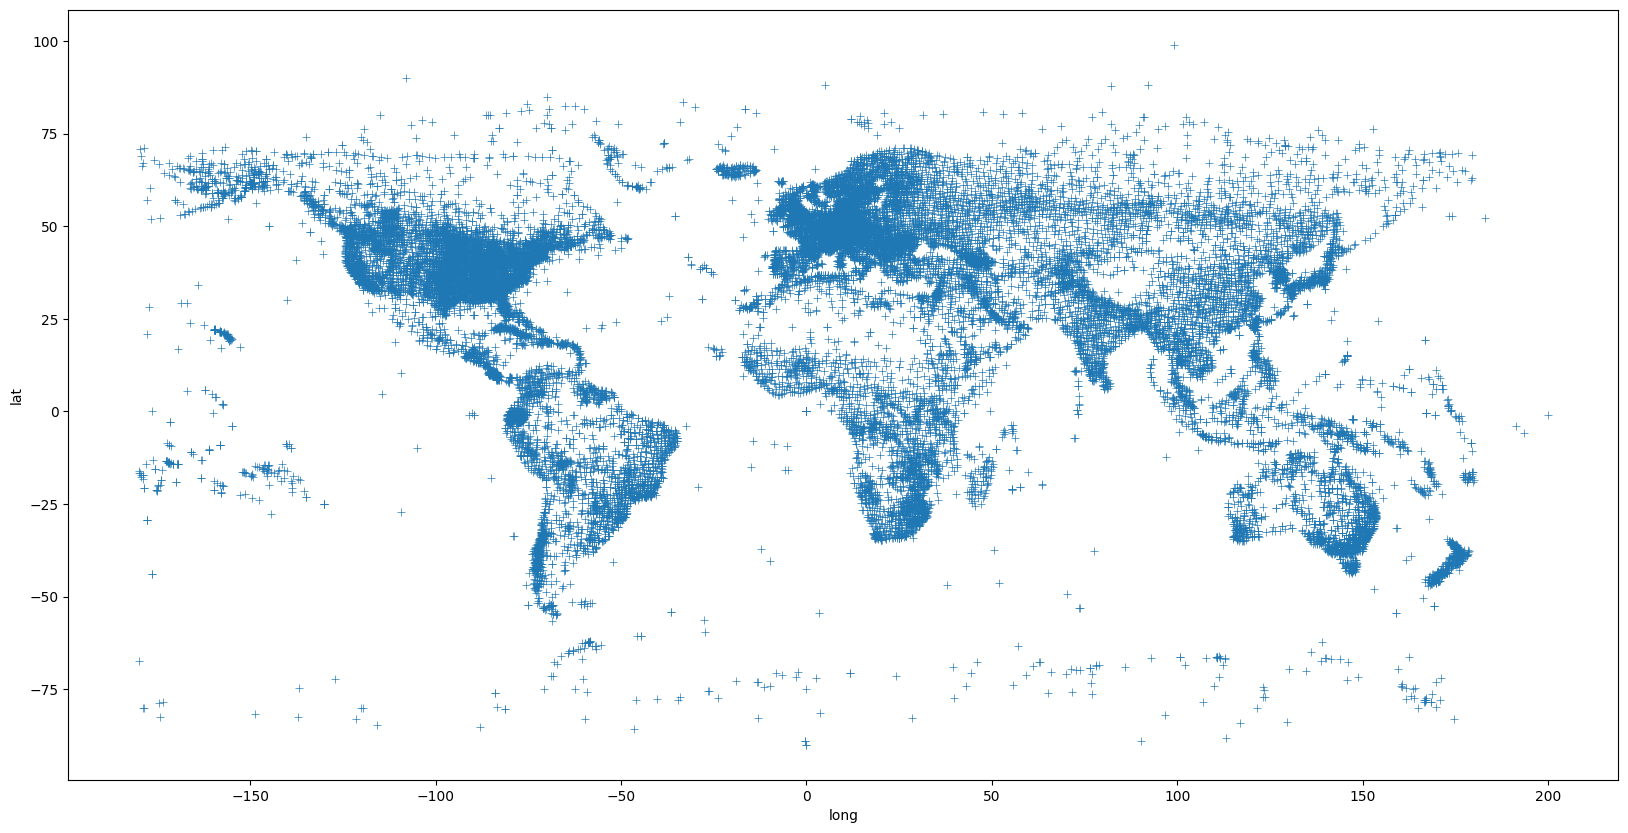

In [6]:
plt.figure(figsize=(20,10))
sns.scatterplot(x=df['long'], y=df['lat'],marker='+')

In [7]:
X = df[['long','lat']]

In [8]:
from sklearn.cluster import KMeans

<Axes: xlabel='long', ylabel='lat'>

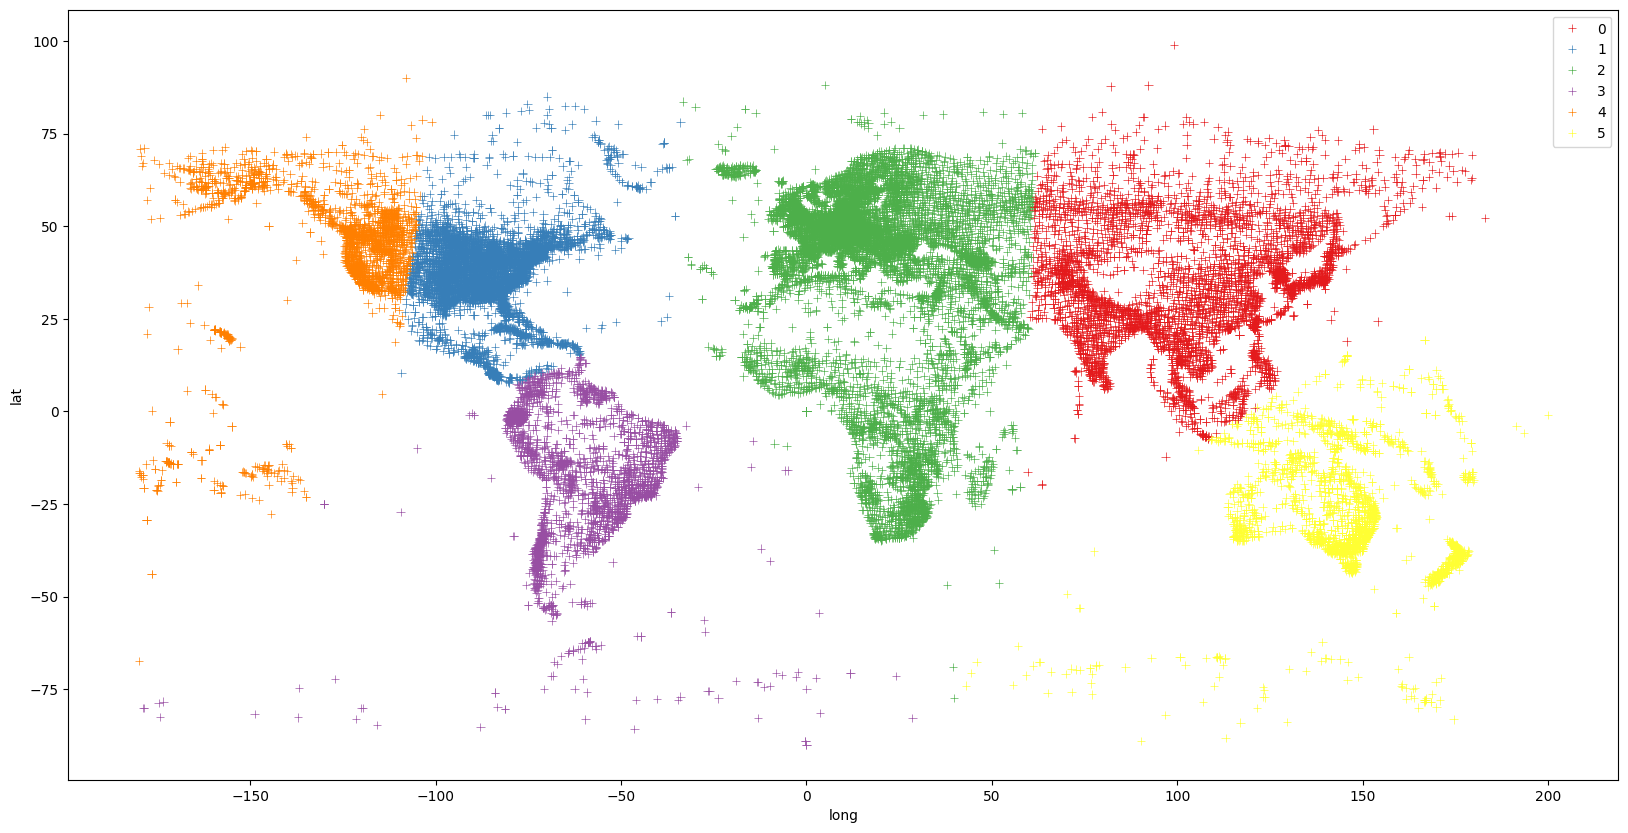

In [9]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(X);
plt.figure(figsize=(20,10))
sns.scatterplot(x=df['long'], y=df['lat'],marker='+', hue=kmeans.labels_, palette="Set1")

In [10]:
err = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    err.append([kmeans.n_clusters, kmeans.inertia_])

err = np.asarray(err)

<Axes: >

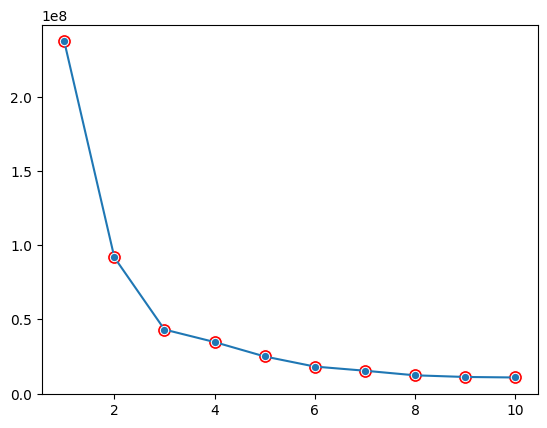

In [11]:
sns.lineplot(x=err[:,0], y=err[:,1], marker='o')
sns.scatterplot(x=err[:,0], y=err[:,1], color='red', s=100)

In [12]:
from sklearn.cluster import DBSCAN

<Axes: xlabel='long', ylabel='lat'>

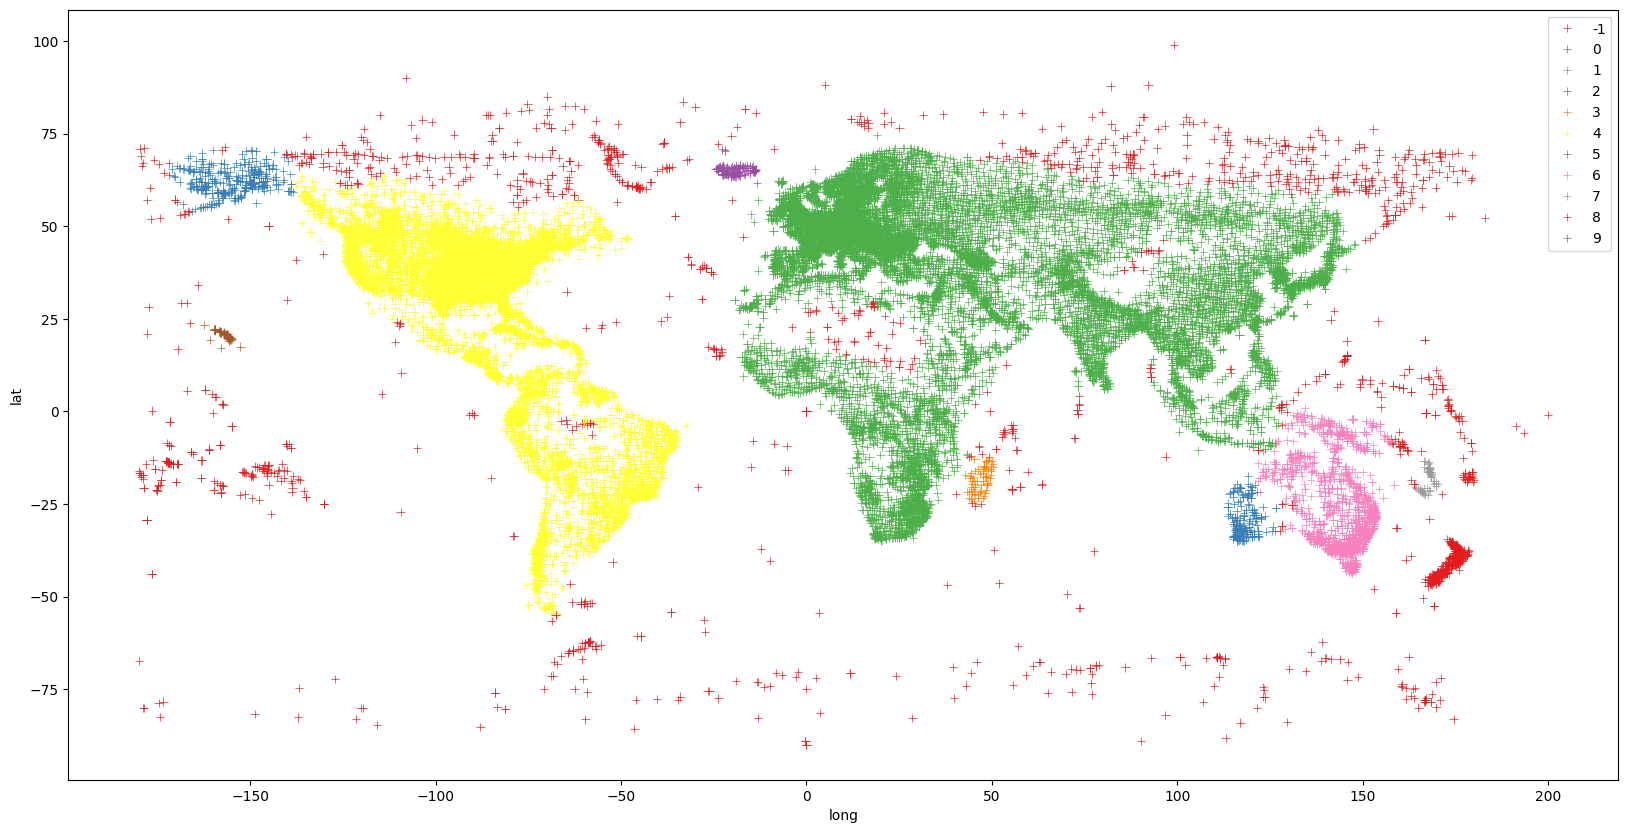

In [13]:
db = DBSCAN(eps=5,min_samples=50)
db.fit(X)
plt.figure(figsize=(20,10))
sns.scatterplot(x=df['long'], y=df['lat'],marker='+', hue=db.labels_, palette="Set1")